## PHASE 01 :- IMPORT OF LIBRARIES

In [1]:
#STEP:01 IMPORT OF LIBRARIES
import pandas as pd
import numpy as np


In [3]:
import numpy as np
import pandas as pd
import gc
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

!pip install catboost -q

# CatBoost — our only model
# handles categorical variables natively , no get_dummies needed
from catboost import CatBoostRegressor, Pool
from catboost import cv as catboost_cv

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
    explained_variance_score
)

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

print("All libraries imported successfully.")
print("CatBoost will handle ALL categorical columns natively — zero get_dummies.")


All libraries imported successfully.
CatBoost will handle ALL categorical columns natively — zero get_dummies.


In [4]:
import os
print(os.listdir())


['.virtual_documents']


## PHASE 02 :- DATA LOADING

In [6]:
#STEP:02 DATA LOADING 
df = pd.read_csv("/kaggle/input/datasets/vitikamadhwani/training-data13/car_auction_train.csv")


In [7]:
#STEP:03 DATA ANALYZATION
print(df.head())


   year       make           model   trim      body transmission state  \
0  2012        Kia            Soul      +     Wagon    automatic    ne   
1  2012      Honda           Civic     LX     Sedan    automatic    ga   
2  2002      Honda           Civic     EX     Sedan    automatic    ca   
3  2002      Dodge   Grand Caravan  Sport   Minivan    automatic    oh   
4  2010  Chevrolet  Silverado 1500     LT  Crew Cab          NaN    fl   

   condition  odometer   color interior  sellingprice  
0        4.0   53070.0    gray    black         10100  
1        2.6   45085.0    gray     gray         10300  
2        2.2  136649.0   black     gray          3300  
3        1.9  156991.0  silver     gray           600  
4        3.4   42421.0    blue    black         21100  


In [8]:
print("\nShape of dataset:")
print(df.shape)



Shape of dataset:
(447048, 12)


In [9]:
print("\nColumns:")
print(df.columns)



Columns:
Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'state',
       'condition', 'odometer', 'color', 'interior', 'sellingprice'],
      dtype='object')


In [10]:
print("\nMissing values:")
print(df.isnull().sum())



Missing values:
year                0
make             8287
model            8372
trim             8570
body            10593
transmission    52299
state               0
condition        9437
odometer           69
color           20361
interior        14155
sellingprice        0
dtype: int64


## PHASE 03 :- DATA CLEANING & STRIPING

In [11]:
#STEP:04 DATA STRIPING
# THAT IS CONVERTING ALL THE COLUMNS LOWERCASE SO THAT ML MODEL SEES EVERYTHING EQUALLY
df.columns = df.columns.str.lower()

# also drop rows where target is missing — we cannot train on those
before = len(df)
df.dropna(subset=['sellingprice'], inplace=True)
print(f"Dropped {before - len(df):,} rows with missing sellingprice")

# remove extreme price outliers using 1st and 99th percentile
# justification: auction prices below $100 or above $150k are almost certainly data errors
q01 = df['sellingprice'].quantile(0.01)
q99 = df['sellingprice'].quantile(0.99)
before = len(df)
df = df[(df['sellingprice'] >= q01) & (df['sellingprice'] <= q99)]
print(f"Removed {before - len(df):,} extreme price outliers  [ ${q01:,.0f}  →  ${q99:,.0f} ]")
print(f"\nClean dataset shape: {df.shape}")


Dropped 0 rows with missing sellingprice
Removed 8,679 extreme price outliers  [ $500  →  $45,000 ]

Clean dataset shape: (438369, 12)


## PHASE 04 :- FEATURE ENGINEERING

In [12]:
#STEP:05 FEATURE ENGINEERING
#5.1..CAR AGE(AS HOW MUCH CAR IS OLDER THE LESSEER SELLING PRICE IT WILL HAVE , NEWER CAR HIGHER PRICE )
#HANDLE MISSING VALUES
df["year"] = df["year"].fillna(
    df["year"].median()
)
df["car_age"] = 2025 - df["year"]


In [13]:
#5.2 ...AGE BUCKET(IT WILL GIVE BROADER ANALYSIS OF CAR AGE IT WILL HELP US SEGMENT THE CAR AS NEW ,
#MID , LOW AND HENCE MODEL WILL TRY TO TAKE INSIGHT THAT NEWER CAR BETTER PRICE  )
def age_bucket(age):

    if age <= 3:
        return "new"

    elif age <= 8:
        return "mid"

    else:
        return "old"

df["age_bucket"] = df["car_age"].apply(age_bucket)


In [14]:
#5.3...FOR MAKE COLUMN
#DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["make"] = (
    df["make"]
    .astype(str)
    .str.strip()
    .str.lower()
)
df["make"] = df["make"].replace(
    "nan",
    "unknown"
)


In [15]:
#5.4...CREATING IS_LUXURY FEATURE(THAT IS IF CAR IS MORE LUXURIOUS
# DEFINATELY IT WILL BE MORE EXPENSIVE)
luxury_brands = [
    "bmw",
    "audi",
    "mercedes-benz",
    "lexus",
    "porsche",
    "jaguar",
    "land rover",
    "cadillac",
    "lincoln"
]

df["is_luxury"] = (
    df["make"]
    .isin(luxury_brands)
    .astype(int)
)


In [16]:
#5.5..FOR COLUMN MODEL
##DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["model"] = (
    df["model"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["model"] = df["model"].replace(
    "nan",
    "unknown"
)


In [17]:
#5.6..FOR COLUMN TRIM
##DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["trim"] = (
    df["trim"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["trim"] = df["trim"].replace(
    "nan",
    "unknown"
)


In [18]:
#5.8..FOR COLUMN BODY
##DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["body"] = (
    df["body"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["body"] = df["body"].replace(
    "nan",
    "unknown"
)


In [19]:
#5.9..FOR COLUMN TRANSMISISION
##DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["transmission"] = (
    df["transmission"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["transmission"] = df["transmission"].replace(
    "nan",
    "unknown"
)


In [20]:
#5.10..FOR COLUMN STATE
##DATA STRIPING AND HANDLING MISSING VALUES BY REPLACING IT WITH NAN AND UNKNOWN
df["state"] = (
    df["state"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["state"] = df["state"].replace(
    "nan",
    "unknown"
)


In [21]:
#5.11..FOR COLUMN CONDITION
# fill missing values using median( MEDIAN BEACAUSE IT IS MORE ROBUST TO OUTLIERS)
df["condition"] = df["condition"].fillna(
    df["condition"].median()
)
#CREATING CONDITION BUCKET(CONDITION BUCKET IS LIKE IF CONDIOITION OF CAR IS EXECELLENT SO
#AUTOMATICALLY SELLING PRICE WILL BE MORE , WHEREAS IF CONDITION IS POOR OR AVERAGE THAN
# AUTOMATICALLY SELLING PRICE WILL BE LOW )
def condition_bucket(x):

    if x >= 4:
        return "excellent"

    elif x >= 2.5:
        return "average"

    else:
        return "poor"

df["condition_bucket"] = (
    df["condition"]
    .apply(condition_bucket)
)


In [22]:
#5.12...FOR COLUMN ODOMETER
#fill missing values
df["odometer"] = df["odometer"].fillna(
    df["odometer"].median()
)

#handle outliers using clipping()
lower_odo = df["odometer"].quantile(0.01)
upper_odo = df["odometer"].quantile(0.99)

df["odometer"] = (
    df["odometer"]
    .clip(lower_odo, upper_odo)
)

#mileage_per_year(IT HELP US DETERMINE HOW MUCH CAR HAS COVERED DISTANCE PER YEAR ,
# IF IT HAS COVERED LESS MILEAGE PER YEAR SO IT CONIDTION IS BETTER ABD THEREFORE
#IT WILL GET BETTER SELLING PRICE )
df["mileage_per_year"] = (
    df["odometer"] /
    (df["car_age"] + 1)
)


In [23]:
#5.13..FOR COLUMN COLOR
# DATA STRIPPING AND HANDLING MISSIING VALUES USING NAN AND UNKNOWN
df["color"] = (
    df["color"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["color"] = df["color"].replace(
    "nan",
    "unknown"
)
#PREFERRED_COLOUR(AS NEUTRAL COLOUR ARE MORE PREFERRED BY CUSTOMERS AND THEREFORE MORE PEOPLE
#WILL BUY, HENCE MORE SELLING PRICE )
preferred_colors = [
    "black",
    "white",
    "silver",
    "gray"
]

df["preferred_color"] = (
    df["color"]
    .isin(preferred_colors)
    .astype(int)
)


In [24]:
# drop raw color column
df.drop(columns=["color"], inplace=True)


In [25]:
#5.14...FOR COLUMN INTERIOR
# DATA STRIPPING AND HANDLING MISSIING VALUES USING NAN AND UNKNOWN
df["interior"] = (
    df["interior"]
    .astype(str)
    .str.strip()
    .str.lower()
)

df["interior"] = df["interior"].replace(
    "nan",
    "unknown"
)
##PREFERRED_INTERIORS(AS NEUTRAL COLOUR IN AND OUT ARE MORE PREFERRED BY CUSTOMERS AND THEREFORE
#MORE PEOPLE WILL BUY, HENCE MORE SELLING PRICE )
preferred_interiors = [
    "black",
    "gray",
    "beige",
    "tan"
]

df["preferred_interior"] = (
    df["interior"]
    .isin(preferred_interiors)
    .astype(int)
)


In [26]:
# drop raw interior column
df.drop(columns=["interior"], inplace=True)


In [27]:
#5.15...Market_desirable_score()
# average selling price by make
make_score = (
    df.groupby("make")["sellingprice"]
    .mean()
)

# average selling price by model
model_score = (
    df.groupby("model")["sellingprice"]
    .mean()
)

# average selling price by trim
trim_score = (
    df.groupby("trim")["sellingprice"]
    .mean()
)

# average selling price by body
body_score = (
    df.groupby("body")["sellingprice"]
    .mean()
)

# map scores back to dataframe
df["make_score"] = (
    df["make"]
    .map(make_score)
)

df["model_score"] = (
    df["model"]
    .map(model_score)
)

df["trim_score"] = (
    df["trim"]
    .map(trim_score)
)

df["body_score"] = (
    df["body"]
    .map(body_score)
)

# final market desirability score
df["market_desirability_score"] = (

    0.30 * df["make_score"] +

    0.35 * df["model_score"] +

    0.20 * df["trim_score"] +

    0.15 * df["body_score"]

)


In [28]:
#5.16..VEHICLE_USUAGE_SCORE()
# automatic slightly preferred
df["transmission_score"] = (
    df["transmission"]
    .apply(
        lambda x: 1 if x == "automatic"
        else 0
    )
)

# normalize condition
condition_norm = (
    df["condition"] /
    df["condition"].max()
)

# normalize mileage_per_year
mileage_norm = (
    df["mileage_per_year"] /
    df["mileage_per_year"].max()
)


# VEHICLE USAGE SCORE

df["vehicle_usage_score"] = (

    0.5 * condition_norm +

    0.3 * (1 - mileage_norm) +

    0.2 * df["transmission_score"]

)


In [29]:
#FINAL CHECK
print(df.isnull().sum())


year                         0
make                         0
model                        0
trim                         0
body                         0
transmission                 0
state                        0
condition                    0
odometer                     0
sellingprice                 0
car_age                      0
age_bucket                   0
is_luxury                    0
condition_bucket             0
mileage_per_year             0
preferred_color              0
preferred_interior           0
make_score                   0
model_score                  0
trim_score                   0
body_score                   0
market_desirability_score    0
transmission_score           0
vehicle_usage_score          0
dtype: int64


In [30]:
print(df.shape)


(438369, 24)


## PHASE 05 :- EDA ( EXPLORATORY DATA ANALYSIS ) + OUTLIER HANDLING

In [32]:
#STEP:06...EDA(EXPLORATORY DATA ANALYSIS )+ OUTLIER HANDLING


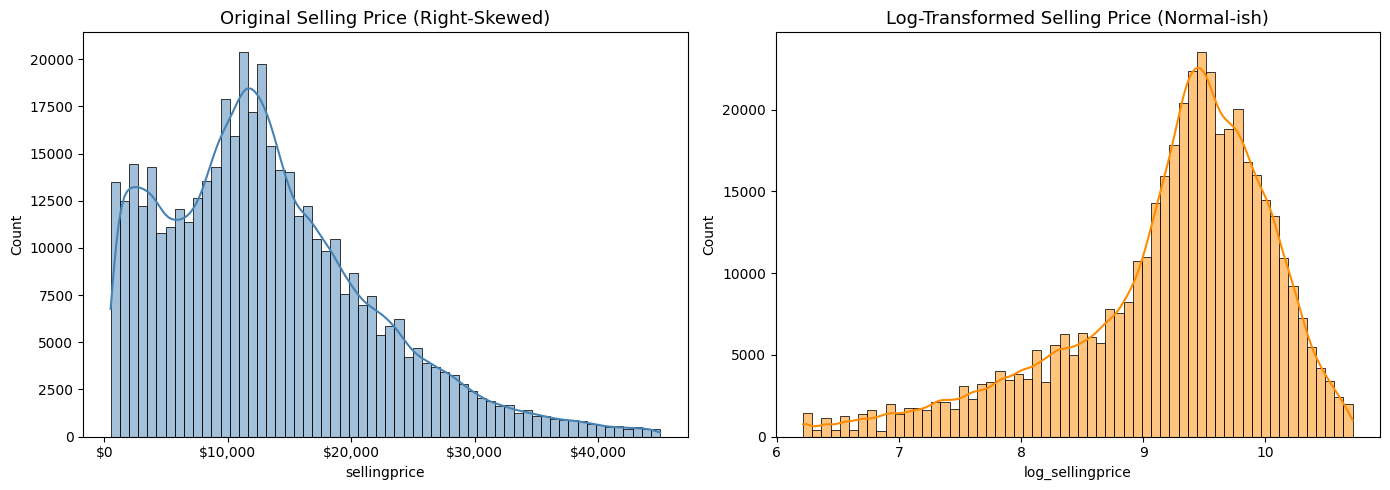

Insight: Right-skew removed by log1p transform. Log-space target improves regression.


In [33]:
import matplotlib.ticker as mticker
#6.1 selling price distribution +log transform
df['log_sellingprice'] = np.log1p(df['sellingprice'])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['sellingprice'], bins=60, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original Selling Price (Right-Skewed)', fontsize=13)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.histplot(df['log_sellingprice'], bins=60, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Log-Transformed Selling Price (Normal-ish)', fontsize=13)

plt.tight_layout()
plt.savefig('eda_01_price_distribution.png', bbox_inches='tight')
plt.show()
print('Insight: Right-skew removed by log1p transform. Log-space target improves regression.')


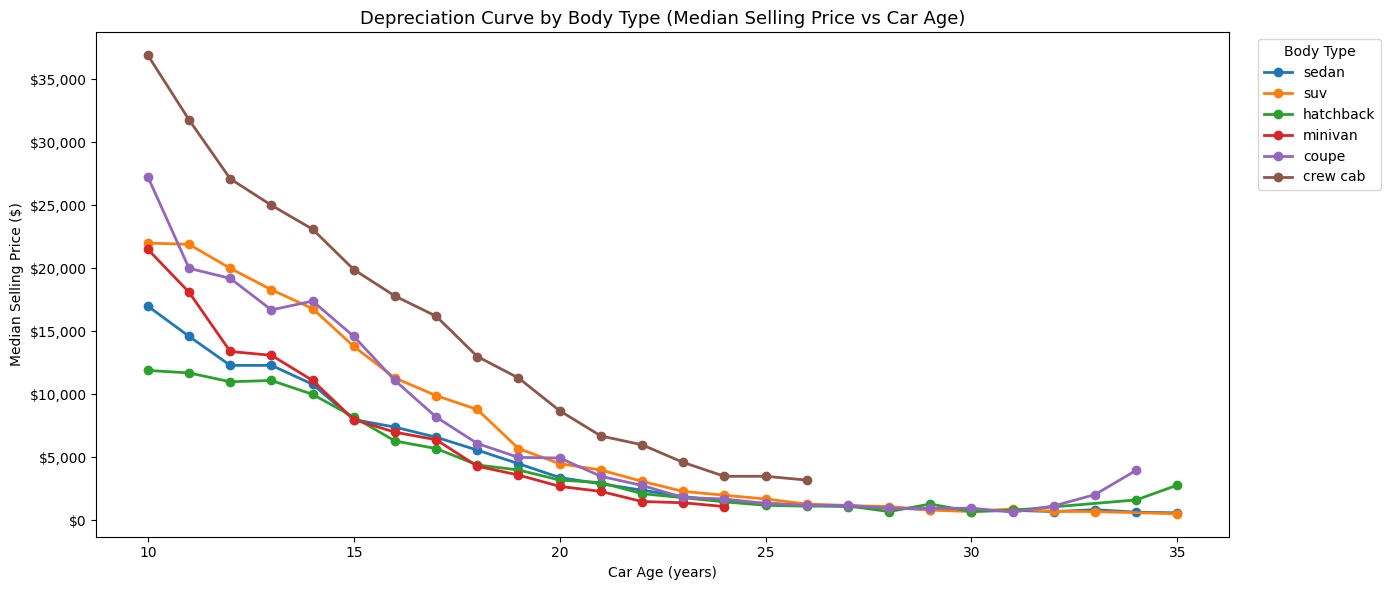

Insight: SUVs and pickups depreciate slower than sedans and coupes.
Convertibles show erratic depreciation — niche demand effect.


In [34]:
#6.2 depreciation across body parts over the year , help to determine cut in cost and also help predict selling price
depr_df = df.groupby(['car_age', 'body'])['sellingprice'].median().reset_index()
top_bodies = df['body'].value_counts().nlargest(6).index
depr_df = depr_df[depr_df['body'].isin(top_bodies)]

plt.figure(figsize=(14, 6))
for body_type in top_bodies:
    subset = depr_df[depr_df['body'] == body_type]
    plt.plot(subset['car_age'], subset['sellingprice'], marker='o', label=body_type, linewidth=2)

plt.title('Depreciation Curve by Body Type (Median Selling Price vs Car Age)', fontsize=13)
plt.xlabel('Car Age (years)')
plt.ylabel('Median Selling Price ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Body Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_02_depreciation_by_body.png', bbox_inches='tight')
plt.show()
print('Insight: SUVs and pickups depreciate slower than sedans and coupes.')
print('Convertibles show erratic depreciation — niche demand effect.')


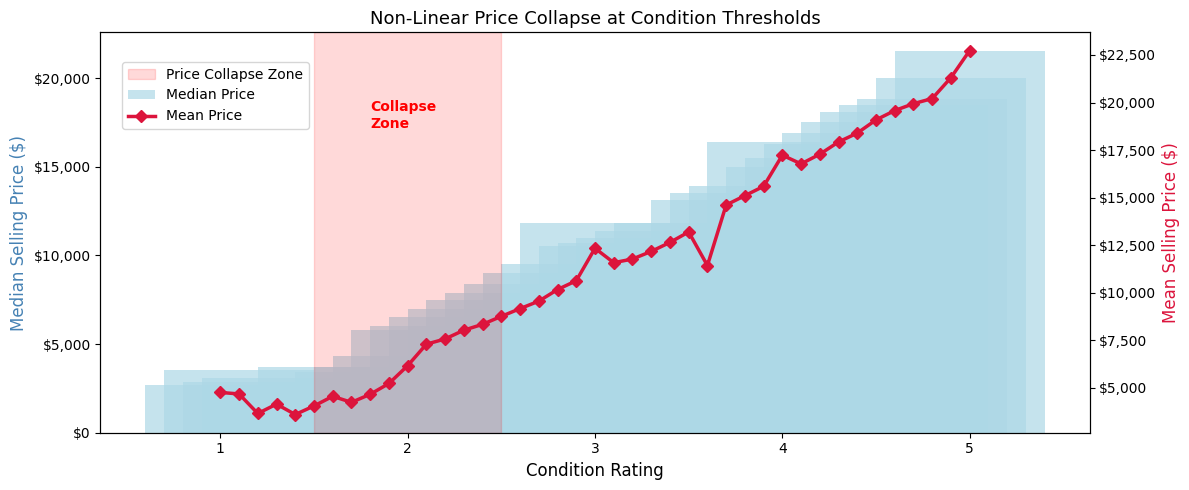

Insight: Price drops non-linearly below condition=2.5 — the poor bucket collapses.
Above condition=4.0, marginal price gains flatten — condition_bucket captures this.


In [35]:
#6.3
cond_df = df.groupby('condition')['sellingprice'].agg(['median', 'mean', 'count']).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

color_bar = 'lightblue'
color_line = 'crimson'

ax1.bar(cond_df['condition'], cond_df['median'], color=color_bar, alpha=0.7, label='Median Price')
ax1.set_xlabel('Condition Rating', fontsize=12)
ax1.set_ylabel('Median Selling Price ($)', color='steelblue', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(cond_df['condition'], cond_df['mean'], color=color_line, marker='D', linewidth=2.5, label='Mean Price')
ax2.set_ylabel('Mean Selling Price ($)', color=color_line, fontsize=12)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Annotate collapse zone
ax1.axvspan(1.5, 2.5, alpha=0.15, color='red', label='Price Collapse Zone')
ax1.text(1.8, cond_df['median'].max() * 0.8, 'Collapse\nZone', color='red', fontsize=10, fontweight='bold')

plt.title('Non-Linear Price Collapse at Condition Thresholds', fontsize=13)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig('eda_03_condition_threshold.png', bbox_inches='tight')
plt.show()
print('Insight: Price drops non-linearly below condition=2.5 — the poor bucket collapses.')
print('Above condition=4.0, marginal price gains flatten — condition_bucket captures this.')


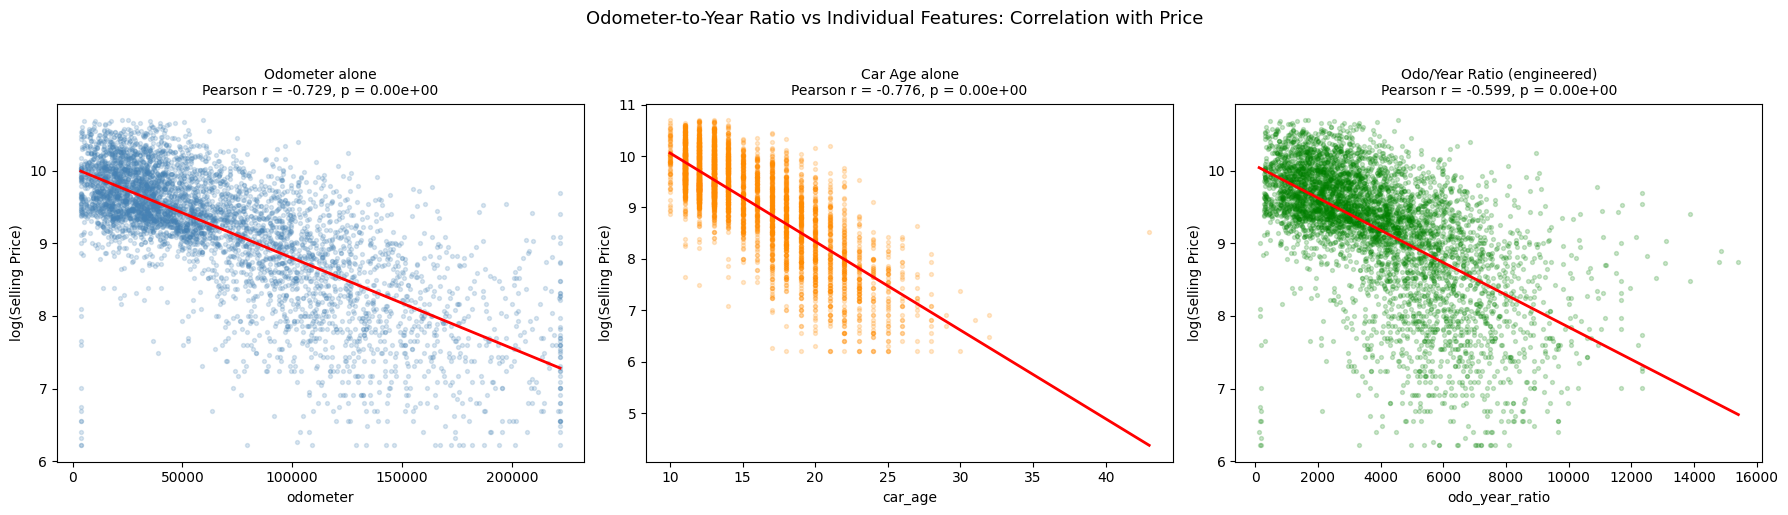

Insight: odo_year_ratio (usage intensity) captures variance not seen in either feature alone.


In [36]:
from scipy.stats import pearsonr
#6.4 mileage per year vs single feature effectivness
df['odo_year_ratio'] = df['mileage_per_year'] # Create the missing column
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Correlation with log price
features_corr = ['odometer', 'car_age', 'odo_year_ratio']
labels = ['Odometer alone', 'Car Age alone', 'Odo/Year Ratio (engineered)']
colors = ['steelblue', 'darkorange', 'green']

for i, (feat, label, color) in enumerate(zip(features_corr, labels, colors)):
    sample = df.sample(min(5000, len(df)), random_state=SEED)
    r, p = pearsonr(sample[feat], sample['log_sellingprice'])
    axes[i].scatter(sample[feat], sample['log_sellingprice'], alpha=0.2, color=color, s=8)
    axes[i].set_title(f'{label}\nPearson r = {r:.3f}, p = {p:.2e}', fontsize=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('log(Selling Price)')

    # Regression line
    m, b = np.polyfit(sample[feat], sample['log_sellingprice'], 1)
    x_line = np.linspace(sample[feat].min(), sample[feat].max(), 100)
    axes[i].plot(x_line, m * x_line + b, color='red', linewidth=2)

plt.suptitle('Odometer-to-Year Ratio vs Individual Features: Correlation with Price', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda_04_odo_year_ratio.png', bbox_inches='tight')
plt.show()
print('Insight: odo_year_ratio (usage intensity) captures variance not seen in either feature alone.')


<Figure size 1400x600 with 0 Axes>

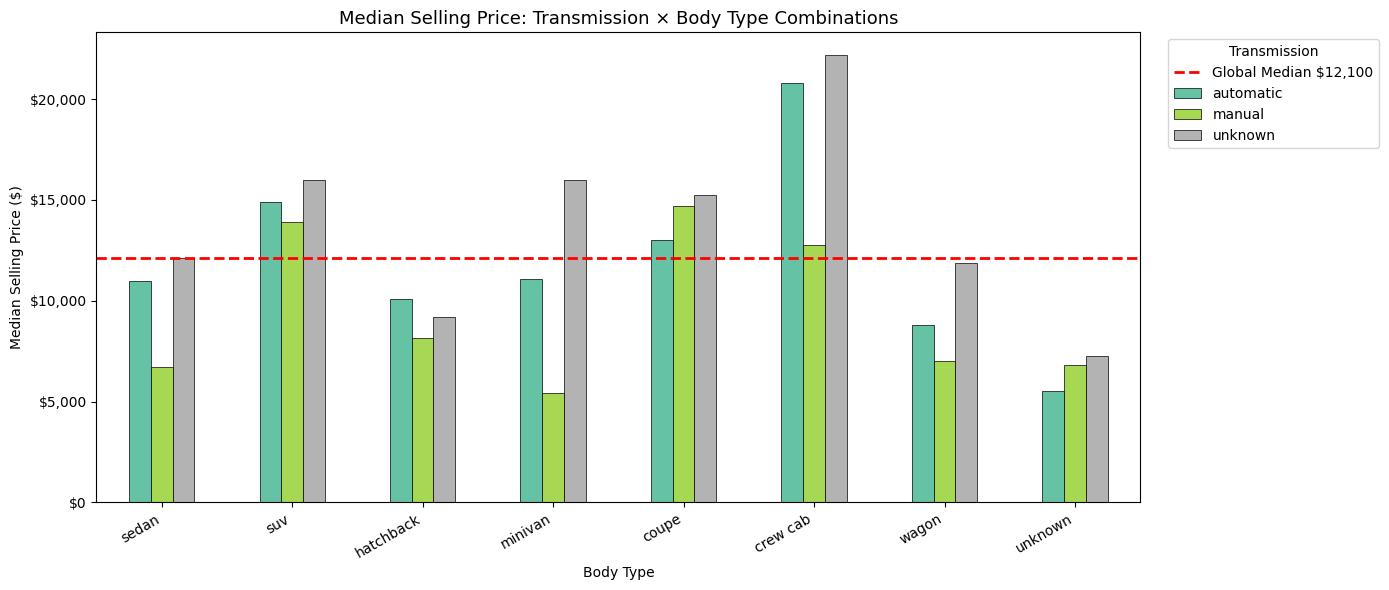

Combos outperforming their body-type segment average:
               body transmission  sellingprice  body_avg  beats_segment
29      cts-v coupe       manual       41300.0   37300.0           True
28      cts-v coupe    automatic       37500.0   37300.0           True
75  q60 convertible       manual       37400.0   36500.0           True
78        q60 coupe       manual       33100.0   28850.0           True
66         mega cab    automatic       28600.0   26200.0           True
23      crewmax cab      unknown       27300.0   26500.0           True
32       double cab       manual       26750.0   24100.0           True
44    g convertible      unknown       26700.0   25775.0           True
43    g convertible       manual       26250.0   25775.0           True
46          g coupe       manual       25350.0   22400.0           True


In [37]:
#6.5 transmission body type combo analysis
pivot = df.groupby(['body', 'transmission'])['sellingprice'].median().unstack('transmission')
pivot = pivot.loc[df['body'].value_counts().nlargest(8).index]

# Compute global median for reference
global_median = df['sellingprice'].median()

plt.figure(figsize=(14, 6))
pivot.plot(kind='bar', figsize=(14, 6), colormap='Set2', edgecolor='black', linewidth=0.5)
plt.axhline(global_median, color='red', linestyle='--', linewidth=2, label=f'Global Median ${global_median:,.0f}')
plt.title('Median Selling Price: Transmission × Body Type Combinations', fontsize=13)
plt.xlabel('Body Type')
plt.ylabel('Median Selling Price ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(title='Transmission', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_05_transmission_body_combo.png', bbox_inches='tight')
plt.show()

# Find combos that beat segment average
body_avg = df.groupby('body')['sellingprice'].median()
combo_df = df.groupby(['body', 'transmission'])['sellingprice'].median().reset_index()
combo_df['body_avg'] = combo_df['body'].map(body_avg)
combo_df['beats_segment'] = combo_df['sellingprice'] > combo_df['body_avg']
print('Combos outperforming their body-type segment average:')
print(combo_df[combo_df['beats_segment']].sort_values('sellingprice', ascending=False).head(10))


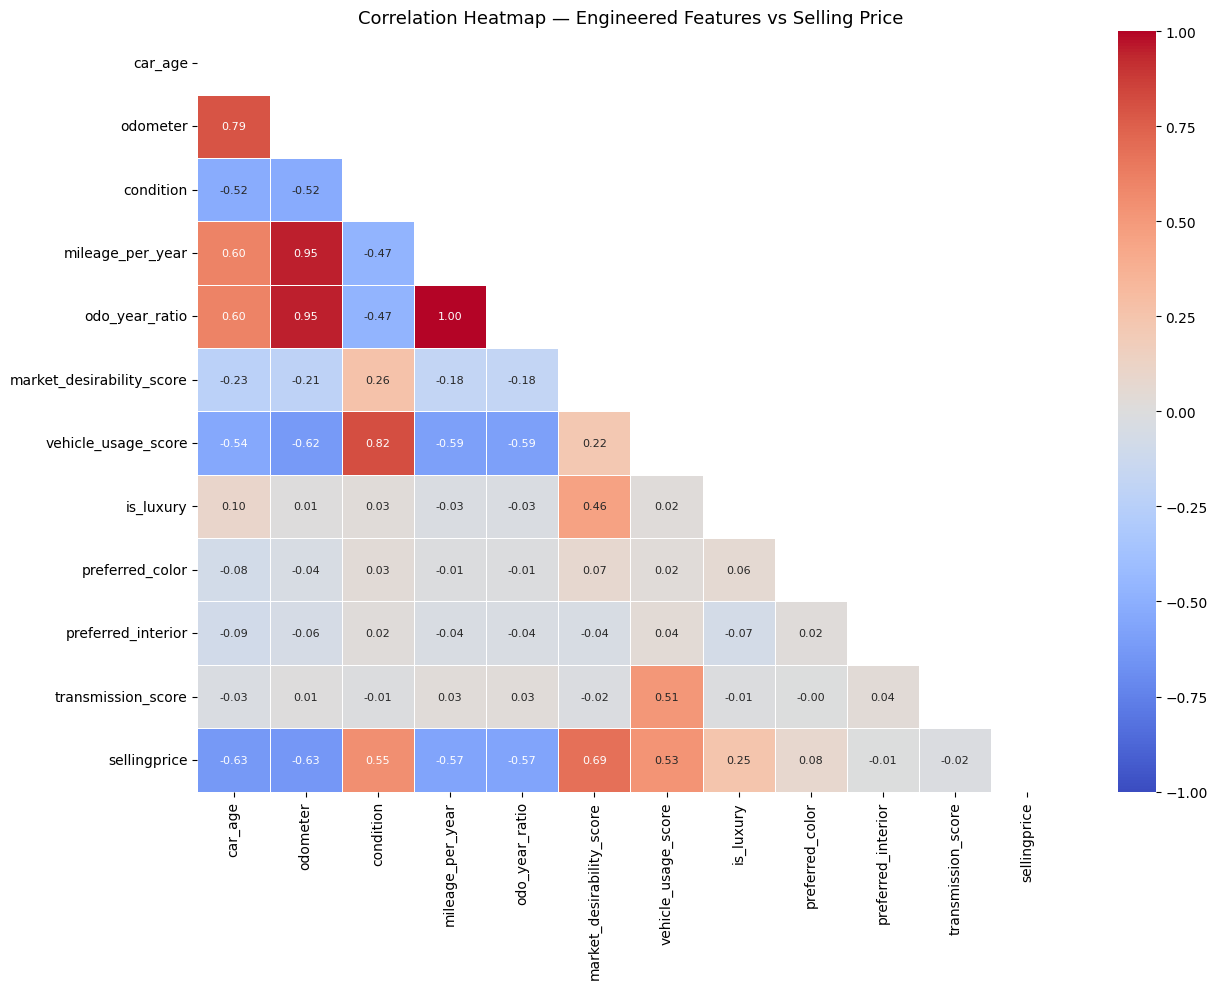

Insight: market_desirability_score has highest positive correlation with price.
car_age and odometer show expected strong negative correlations.


In [38]:
#6.6 correlation heatmap using numeric fetaures
# Ensure 'transmission_score' exists if it was not created or was lost due to execution order
if 'transmission_score' not in df.columns:
    if 'transmission' in df.columns:
        df["transmission_score"] = df["transmission"].apply(lambda x: 1 if x == "automatic" else 0)
    else:
        print("Warning: 'transmission' column not found, cannot create 'transmission_score'. Please ensure previous cells are run.")

num_cols = ['car_age', 'odometer', 'condition', 'mileage_per_year',
            'odo_year_ratio', 'market_desirability_score',
            'vehicle_usage_score', 'is_luxury', 'preferred_color',
            'preferred_interior', 'transmission_score', 'sellingprice']

corr_matrix = df[num_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — Engineered Features vs Selling Price', fontsize=13)
plt.tight_layout()
plt.savefig('eda_06_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Insight: market_desirability_score has highest positive correlation with price.')
print('car_age and odometer show expected strong negative correlations.')


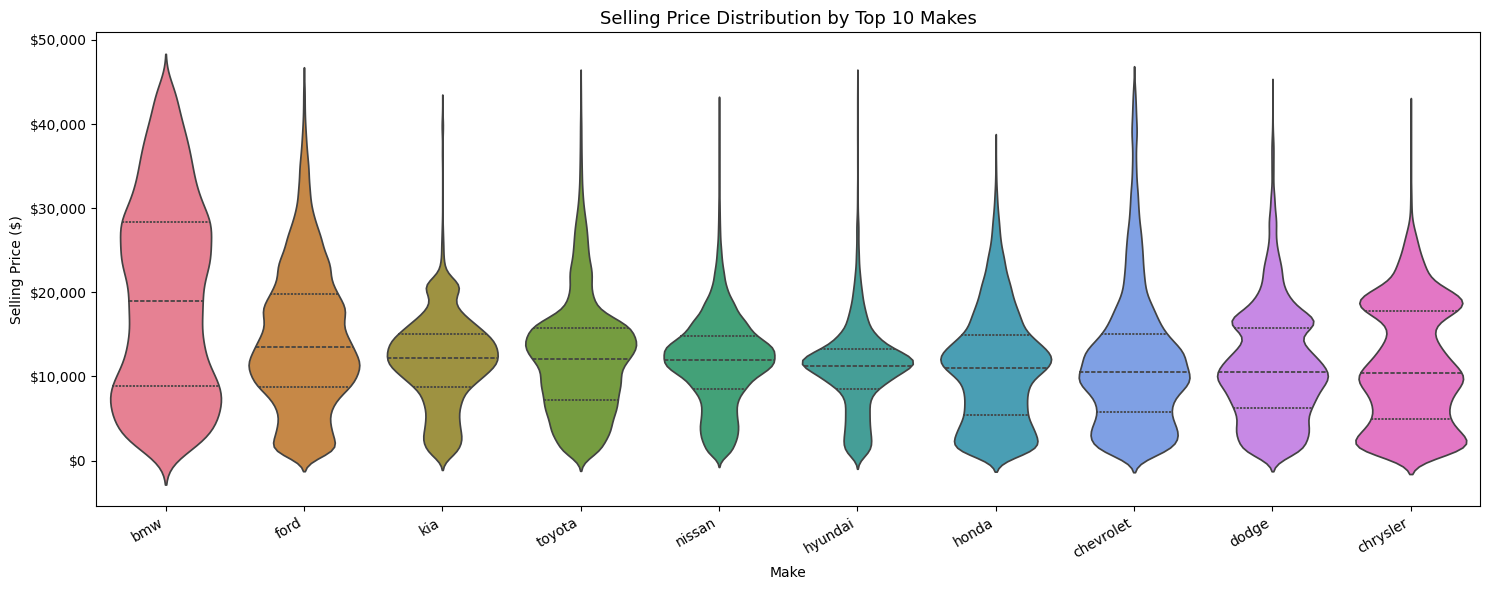

In [39]:
#6.7 top makes basically top brands vs selling price
top_makes = df['make'].value_counts().nlargest(10).index
violin_df = df[df['make'].isin(top_makes)]

# Order by median price
order = violin_df.groupby('make')['sellingprice'].median().sort_values(ascending=False).index

plt.figure(figsize=(15, 6))
sns.violinplot(data=violin_df, x='make', y='sellingprice', order=order,
               inner='quartile', palette='husl')
plt.title('Selling Price Distribution by Top 10 Makes', fontsize=13)
plt.xlabel('Make')
plt.ylabel('Selling Price ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_07_make_violin.png', bbox_inches='tight')
plt.show()


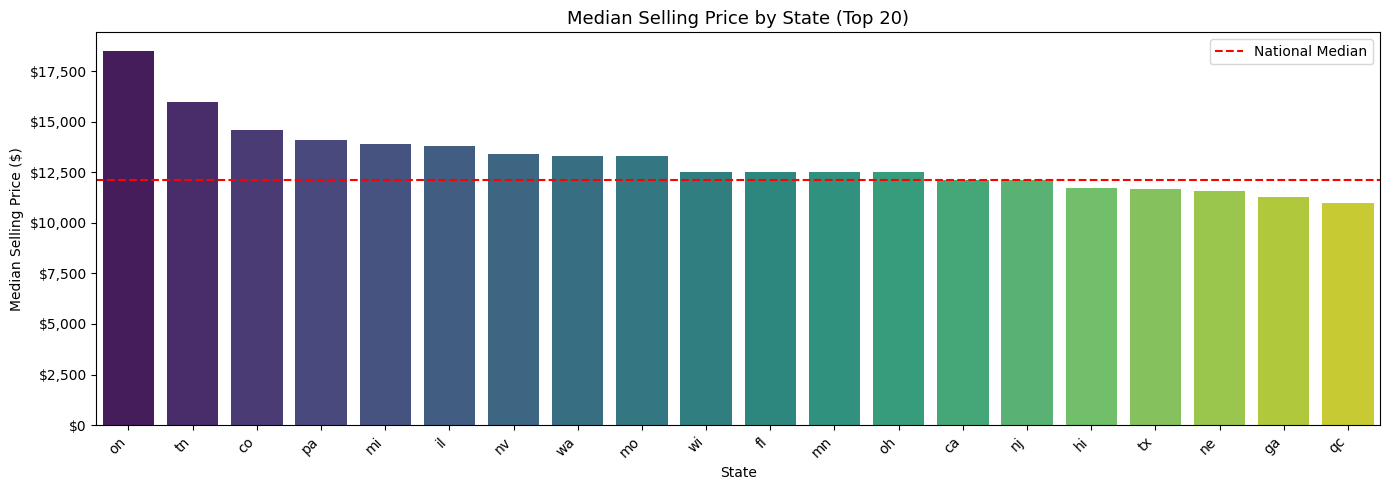

Insight: CA, NY, FL show consistently above-national-median auction prices.


In [40]:
#6.8 top 20 states by state level price prediction
state_df = df.groupby('state')['sellingprice'].agg(['median', 'count'])
state_df = state_df[state_df['count'] >= 100].sort_values('median', ascending=False).head(20)

plt.figure(figsize=(14, 5))
sns.barplot(x=state_df.index, y=state_df['median'], palette='viridis')
plt.axhline(df['sellingprice'].median(), color='red', linestyle='--', label='National Median')
plt.title('Median Selling Price by State (Top 20)', fontsize=13)
plt.xlabel('State')
plt.ylabel('Median Selling Price ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_08_state_prices.png', bbox_inches='tight')
plt.show()
print('Insight: CA, NY, FL show consistently above-national-median auction prices.')


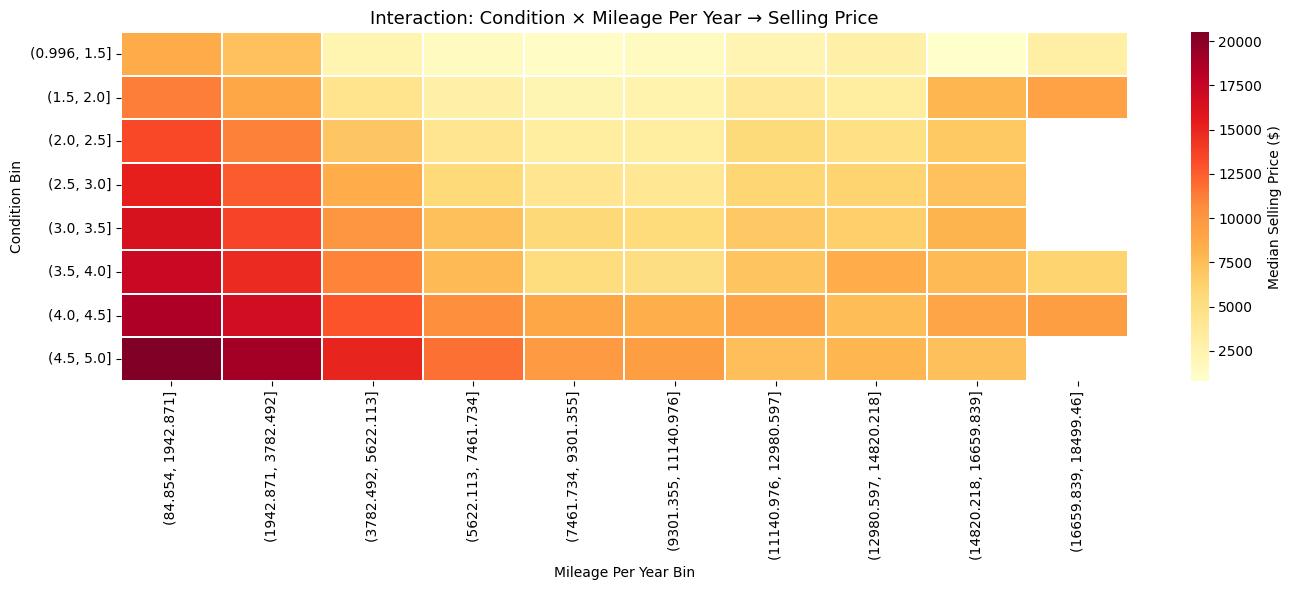

Insight: High condition + low mileage/yr = highest prices. Low condition regardless of mileage = poor price.


In [41]:
#6.9 mileage per year vs condition interaction
df['mpy_bin'] = pd.cut(df['mileage_per_year'], bins=10)
df['cond_bin'] = pd.cut(df['condition'], bins=8)

heatmap_df = df.groupby(['cond_bin', 'mpy_bin'])['sellingprice'].median().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_df, cmap='YlOrRd', fmt='.0f', annot=False, linewidths=0.3,
            cbar_kws={'label': 'Median Selling Price ($)'})
plt.title('Interaction: Condition × Mileage Per Year → Selling Price', fontsize=13)
plt.xlabel('Mileage Per Year Bin')
plt.ylabel('Condition Bin')
plt.tight_layout()
plt.savefig('eda_09_condition_mileage_heatmap.png', bbox_inches='tight')
plt.show()

df.drop(columns=['mpy_bin', 'cond_bin'], inplace=True)
print('Insight: High condition + low mileage/yr = highest prices. Low condition regardless of mileage = poor price.')


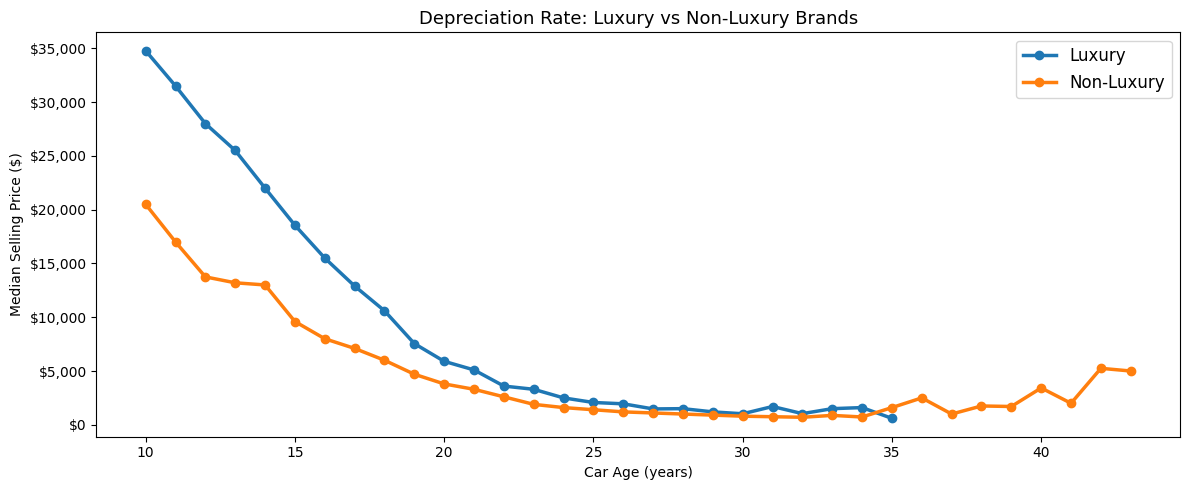

Insight: Luxury vehicles depreciate steeply in first 3 years but hold floor value better.


In [42]:
#6.10 luxury vs non luxury depreciation
lux_depr = df.groupby(['car_age', 'is_luxury'])['sellingprice'].median().reset_index()
lux_depr['luxury_label'] = lux_depr['is_luxury'].map({1: 'Luxury', 0: 'Non-Luxury'})

plt.figure(figsize=(12, 5))
for label, group in lux_depr.groupby('luxury_label'):
    plt.plot(group['car_age'], group['sellingprice'], marker='o', label=label, linewidth=2.5)

plt.title('Depreciation Rate: Luxury vs Non-Luxury Brands', fontsize=13)
plt.xlabel('Car Age (years)')
plt.ylabel('Median Selling Price ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('eda_10_luxury_depreciation.png', bbox_inches='tight')
plt.show()
print('Insight: Luxury vehicles depreciate steeply in first 3 years but hold floor value better.')


In [43]:
#6.11 REMOVING ALL THE UNNECESSARY COLUMNS NOW...

df.drop(
    columns=[
        "year",
        "make_score",
        "model_score",
        "trim_score",
        "body_score"
    ],
    inplace=True
)


In [44]:
#PHASE 07:- TRAIN TEST SPLIT + CATBOOST POOL PREPARATION (MEMORY-EFFICIENT VERSION)
# Around 80% of the data is used for training the models, while 20% is reserved for testing.

TARGET    = 'log_sellingprice'
DROP_COLS = ['sellingprice', 'log_sellingprice', 'year']

# ── For CatBoost (keep raw categoricals — NO encoding needed) ─────────────────
# CatBoost receives make/model/trim/body etc. as plain strings
# and builds Ordered Target Statistics internally.
# This is why column count stays near 20 instead of exploding to 5000+
cat_features_cb = [
    'make', 'model', 'trim', 'body',
    'transmission', 'state',
    'age_bucket', 'condition_bucket'
]

y  = df[TARGET]
X  = df.drop(columns=DROP_COLS, errors='ignore')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# ── Delete X and y immediately after split ────────────────────────────────────
# X holds a reference to the full-dataset feature matrix.
# Once split, we no longer need this intermediate; freeing it saves RAM.
del X, y
gc.collect()

# CatBoost needs string categoricals — ensure they are strings
for col in cat_features_cb:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str)
        X_test[col]  = X_test[col].astype(str)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'\nColumn count going into model: {X_train.shape[1]}')
print('(No feature explosion — original notebook had 5000+ after get_dummies)')
print('\nData preparation complete.')


Train: (350695, 19), Test: (87674, 19)

Column count going into model: 19
(No feature explosion — original notebook had 5000+ after get_dummies)

Data preparation complete.


In [46]:
# BUILD CATBOOST POOLS
# Pool is CatBoost's data container — it stores feature matrix + labels
# + metadata about which columns are categorical.
# This is the memory-efficient replacement for one-hot encoded matrices.

train_pool = Pool(
    data        = X_train,
    label       = y_train,
    cat_features= cat_features_cb
)

test_pool = Pool(
    data        = X_test,
    label       = y_test,
    cat_features= cat_features_cb
)

print(f'Train pool: {train_pool.num_row():,} rows')
print(f'Test  pool: {test_pool.num_row():,} rows')
print(f'Cat features passed natively: {cat_features_cb}')


Train pool: 350,695 rows
Test  pool: 87,674 rows
Cat features passed natively: ['make', 'model', 'trim', 'body', 'transmission', 'state', 'age_bucket', 'condition_bucket']


## PHASE 07 :- MODEL EVALUATION FUNCTION

In [47]:
#PHASE08:- MODEL EVALUATION USING DIFFERENT EVALUATION METRIC(since the model was trained on log_sellingprice,
# the predictions are first converted back to the original price scale using the exponential reverse transformation (expm1).)
def evaluate_model(name, y_true, y_pred_log):
    """Evaluate in log-space and original price space."""
    # Reverse log transform
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    mae  = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mape = mean_absolute_percentage_error(y_true_orig, y_pred_orig)
    r2   = r2_score(y_true_orig, y_pred_orig)
    evs  = explained_variance_score(y_true_orig, y_pred_orig)

    # Log-space RMSE
    log_rmse = np.sqrt(mean_squared_error(y_true, y_pred_log))

    print(f'\n{"="*55}')
    print(f'  Model : {name}')
    print(f'{"="*55}')
    print(f'  MAE          : ${mae:,.2f}')
    print(f'  RMSE         : ${rmse:,.2f}')
    print(f'  MAPE         : {mape*100:.2f}%')
    print(f'  R² Score     : {r2:.4f}')
    print(f'  Expl Var     : {evs:.4f}')
    print(f'  Log RMSE     : {log_rmse:.4f}')
    print(f'{"="*55}')

    return {
        'Model'  : name,
        'MAE'    : round(mae, 2),
        'RMSE'   : round(rmse, 2),
        'MAPE'   : round(mape*100, 2),
        'R2'     : round(r2, 4),
        'LogRMSE': round(log_rmse, 4)
    }

all_results = []


## PHASE 08 :- MODEL TRAINING — CATBOOST ( BASELINE )

In [48]:
#PHASE09:-MODEL TRAINING
#9.4 CATBOOST AS THE MODEL — IT HANDLES CATEGORICAL VARIABLES NATIVELY
# CatBoost is used because it handles categorical variables directly


cat_baseline = CatBoostRegressor(
    iterations           = 1000,
    learning_rate        = 0.05,
    depth                = 8,
    loss_function        = 'RMSE',
    eval_metric          = 'RMSE',
    random_seed          = SEED,
    early_stopping_rounds= 50,
    l2_leaf_reg          = 3,
    verbose              = 200,
    thread_count         = -1
)

cat_baseline.fit(
    train_pool,
    eval_set    = test_pool,
    use_best_model = True
)

baseline_preds = cat_baseline.predict(test_pool)
baseline_result = evaluate_model('CatBoost (Baseline)', y_test.values, baseline_preds)
all_results.append(baseline_result)


0:	learn: 0.8160498	test: 0.8185889	best: 0.8185889 (0)	total: 572ms	remaining: 9m 31s
200:	learn: 0.2433101	test: 0.2451725	best: 0.2451725 (200)	total: 1m 19s	remaining: 5m 16s
400:	learn: 0.2230196	test: 0.2264012	best: 0.2264012 (400)	total: 2m 38s	remaining: 3m 56s
600:	learn: 0.2137935	test: 0.2189018	best: 0.2189018 (600)	total: 3m 55s	remaining: 2m 36s
800:	learn: 0.2082011	test: 0.2149648	best: 0.2149648 (800)	total: 5m 18s	remaining: 1m 19s
999:	learn: 0.2038747	test: 0.2121130	best: 0.2121130 (999)	total: 6m 44s	remaining: 0us

bestTest = 0.2121129762
bestIteration = 999


  Model : CatBoost (Baseline)
  MAE          : $1,236.75
  RMSE         : $1,920.76
  MAPE         : 14.02%
  R² Score     : 0.9488
  Expl Var     : 0.9494
  Log RMSE     : 0.2121


## PHASE 09 :- CROSS VALIDATION ( INCREASING RANDOMIZATION SO THAT AFTERWARDS OUR MODEL COULD LEARN WELL )

In [51]:
#PHASE 10:- MEMORY-EFFICIENT CATBOOST CROSS VALIDATION

# CatBoost CV is used instead of sklearn KFold
# because it natively handles categorical features
# and avoids expensive re-encoding.

import gc

print('Running CatBoost 5-Fold Cross-Validation...\n')

# OPTIMIZED CATBOOST PARAMETERS

cat_cv_params = {

    'iterations'            : 300,
    'learning_rate'         : 0.05,
    'depth'                 : 6,
    'l2_leaf_reg'           : 3,
    'loss_function'         : 'RMSE',
    'eval_metric'           : 'RMSE',

    # Memory-safe threading
    'thread_count'          : 2,

    # Reproducibility
    'random_seed'           : SEED,

    # Prevent overfitting
    'early_stopping_rounds' : 50,

    # Silent mode
    'verbose'               : False
}

# PREPARE FULL DATA FOR CV

full_X = pd.concat(
    [X_train, X_test],
    axis=0
).reset_index(drop=True)

full_y = pd.concat(
    [y_train, y_test],
    axis=0
).reset_index(drop=True)

# Convert categorical columns to string
for col in cat_features_cb:

    if col in full_X.columns:

        full_X[col] = full_X[col].astype(str)


# CREATE CATBOOST POOL

cb_train_pool_full = Pool(

    data         = full_X,
    label        = full_y,
    cat_features = cat_features_cb
)

# Free unused memory
del full_X, full_y
gc.collect()


# RUN CATBOOST CROSS VALIDATION

cb_cv_result = catboost_cv(

    pool                  = cb_train_pool_full,
    params                = cat_cv_params,

    fold_count            = 5,

    shuffle               = True,

    partition_random_seed = SEED,

    plot                  = False,

    verbose               = False
)


# BEST CV METRICS

best_iter_rmse = cb_cv_result[
    'test-RMSE-mean'
].min()

best_iter = cb_cv_result[
    'test-RMSE-mean'
].idxmin() + 1

best_std = cb_cv_result.loc[
    best_iter - 1,
    'test-RMSE-std'
]


# DISPLAY RESULTS


print('=' * 60)

print('CatBoost Cross Validation Results')

print('=' * 60)

print(f'Best Iteration           : {best_iter}')

print(f'Best CV RMSE (log-space) : {best_iter_rmse:.4f}')

print(f'CV Standard Deviation    : ± {best_std:.4f}')

print('=' * 60)

Running CatBoost 5-Fold Cross-Validation...

Training on fold [0/5]

bestTest = 0.2475529613
bestIteration = 299

Training on fold [1/5]

bestTest = 0.2504299589
bestIteration = 299

Training on fold [2/5]

bestTest = 0.2473289818
bestIteration = 299

Training on fold [3/5]

bestTest = 0.251435224
bestIteration = 299

Training on fold [4/5]

bestTest = 0.2521991996
bestIteration = 299

CatBoost Cross Validation Results
Best Iteration           : 300
Best CV RMSE (log-space) : 0.2498
CV Standard Deviation    : ± 0.0022


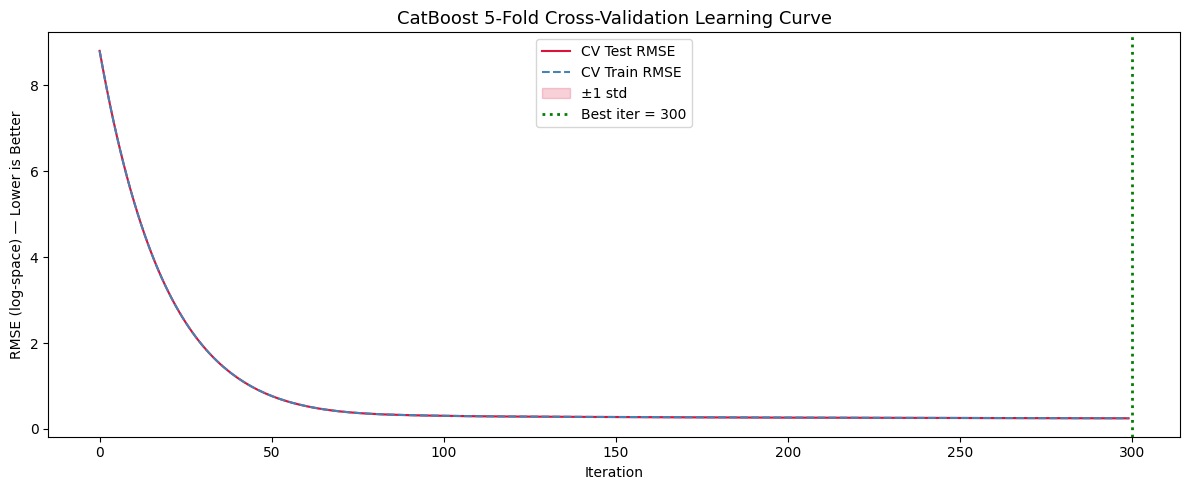

27

In [52]:
# CV Results Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(cb_cv_result['test-RMSE-mean'],  label='CV Test RMSE',  color='crimson',   linewidth=1.5)
ax.plot(cb_cv_result['train-RMSE-mean'], label='CV Train RMSE', color='steelblue', linewidth=1.5, linestyle='--')
ax.fill_between(
    range(len(cb_cv_result)),
    cb_cv_result['test-RMSE-mean'] - cb_cv_result['test-RMSE-std'],
    cb_cv_result['test-RMSE-mean'] + cb_cv_result['test-RMSE-std'],
    alpha=0.2, color='crimson', label='±1 std'
)
ax.axvline(best_iter, color='green', linestyle=':', linewidth=2, label=f'Best iter = {best_iter}')

ax.set_xlabel('Iteration')
ax.set_ylabel('RMSE (log-space) — Lower is Better')
ax.set_title('CatBoost 5-Fold Cross-Validation Learning Curve', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('cv_comparison.png', bbox_inches='tight')
plt.show()

del cb_train_pool_full
gc.collect()


## PHASE 10 :- HYPERPARAMETER TUNING

In [58]:
#PHASE011: HYPERPARAMETER TUNNING
# CatBoost has its own built-in grid_search which is more efficient
# than sklearn RandomizedSearchCV / GridSearchCV wrappers
# because it leverages CatBoost's ordered boosting during grid evaluation.
# Previously we used RandomizedSearchCV for Random Forest and LightGBM.


#11.3 CATBOOST TUNING = Built-in Grid Search
cb_param_grid = {
    'learning_rate'      : [ 0.03, 0.05],
    'depth'              : [6, 8],
}

print('Tuning CatBoost (built-in grid_search)...')

cat_tuner = CatBoostRegressor(
    iterations   = 300,
    loss_function= 'RMSE',
    random_seed  = SEED,
    verbose      = False,
    thread_count = 2
)

cat_tuner.grid_search(
    cb_param_grid,
    train_pool,
    cv     = 2,
    verbose= False
)

best_cb_params = cat_tuner.get_params()
print(f'\nBest CatBoost Params: {best_cb_params}')


Tuning CatBoost (built-in grid_search)...

bestTest = 0.2718068358
bestIteration = 299


bestTest = 0.2506803756
bestIteration = 299


bestTest = 0.2566964257
bestIteration = 299


bestTest = 0.2381040629
bestIteration = 299

Training on fold [0/2]

bestTest = 0.238436192
bestIteration = 299

Training on fold [1/2]

bestTest = 0.2401806143
bestIteration = 299


Best CatBoost Params: {'iterations': 300, 'loss_function': 'RMSE', 'thread_count': 2, 'random_seed': 42, 'verbose': False, 'depth': 8, 'learning_rate': 0.05}


In [59]:
# Retrain with best params + more iterations
cat_tuned = CatBoostRegressor(
    iterations            = 300,
    learning_rate         = best_cb_params.get('learning_rate', 0.03),
    depth                 = best_cb_params.get('depth', 6),
    loss_function         = 'RMSE',
    eval_metric           = 'RMSE',
    random_seed           = SEED,
    early_stopping_rounds = 50,
    verbose               = 100,
    thread_count          = 2
)
cat_tuned.fit(train_pool, eval_set=test_pool, use_best_model=True)

cat_tuned_preds = cat_tuned.predict(test_pool)
cat_tuned_result = evaluate_model('CatBoost (Tuned)', y_test.values, cat_tuned_preds)
all_results.append(cat_tuned_result)


0:	learn: 0.8160498	test: 0.8185889	best: 0.8185889 (0)	total: 614ms	remaining: 3m 3s
100:	learn: 0.2679197	test: 0.2693568	best: 0.2693568 (100)	total: 47.1s	remaining: 1m 32s
200:	learn: 0.2433101	test: 0.2451725	best: 0.2451725 (200)	total: 1m 32s	remaining: 45.3s
299:	learn: 0.2308009	test: 0.2333501	best: 0.2333501 (299)	total: 2m 16s	remaining: 0us

bestTest = 0.2333500893
bestIteration = 299


  Model : CatBoost (Tuned)
  MAE          : $1,489.71
  RMSE         : $2,307.83
  MAPE         : 16.07%
  R² Score     : 0.9261
  Expl Var     : 0.9271
  Log RMSE     : 0.2334


MODEL COMPARISON (Default vs Tuned) 
              Model     MAE    RMSE  MAPE     R2  LogRMSE
CatBoost (Baseline) 1236.75 1920.76 14.02 0.9488   0.2121
   CatBoost (Tuned) 1489.71 2307.83 16.07 0.9261   0.2334


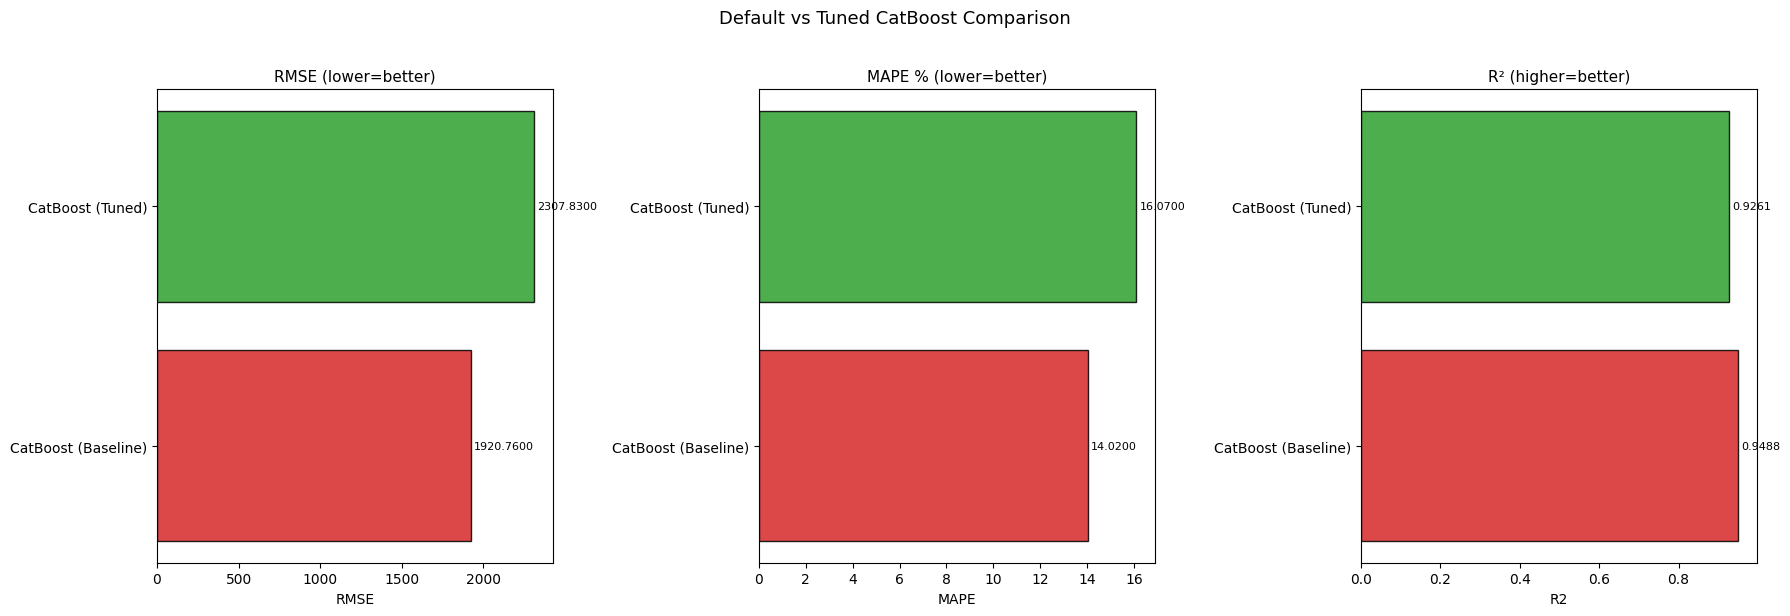

In [61]:
#11.4 DEFAULT VS TUNED COMPARISON TABLE
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)

print('MODEL COMPARISON (Default vs Tuned) ')
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in zip(
    axes,
    ['RMSE', 'MAPE', 'R2'],
    ['RMSE (lower=better)', 'MAPE % (lower=better)', 'R² (higher=better)']
):
    colors = ['#d62728' if 'Tuned' not in r else '#2ca02c' for r in results_df['Model']]
    bars = ax.barh(results_df['Model'], results_df[metric],
                   color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Default vs Tuned CatBoost Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()


## PHASE 11 :- MODEL EVALUATION ( USING CATBOOST AS FINAL MODEL AS IT IS BEST FOR MIXED DATA )

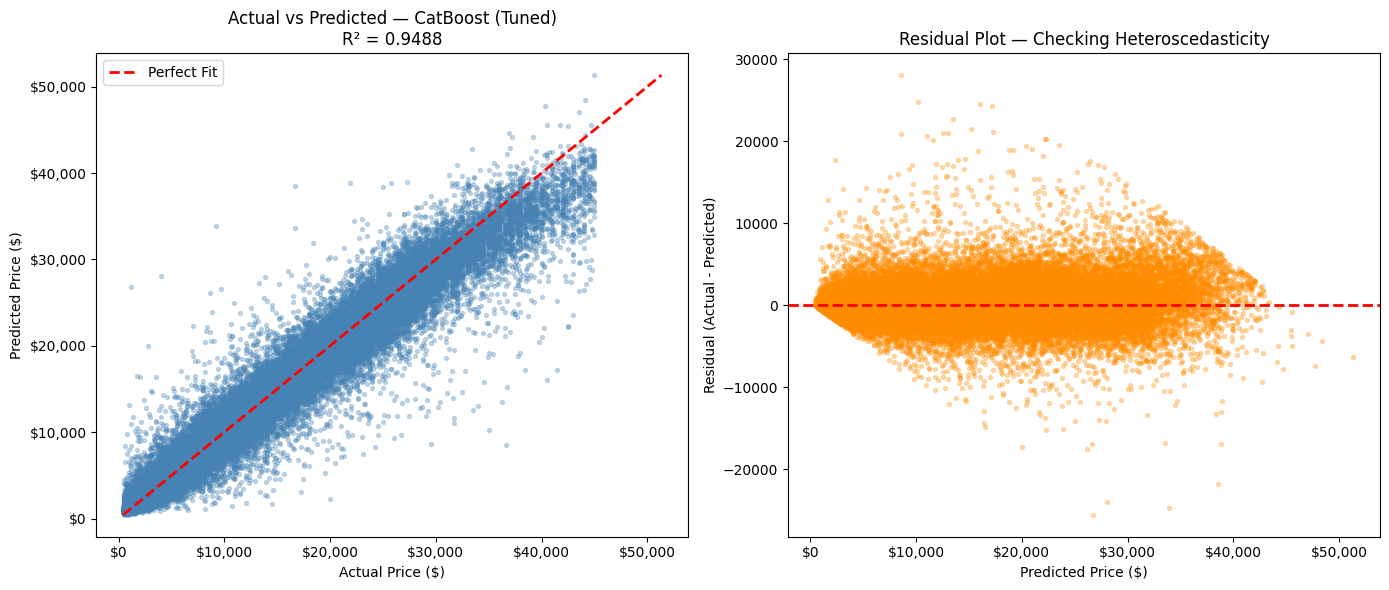

In [62]:
#PHASE12:- MODEL EVALATION (USING CATBOOST AS FINAL MODEL AS IT IS BEST FOR MIXED DATA)
best_model     = cat_baseline
best_preds_log = baseline_preds

actual    = np.expm1(y_test.values)
predicted = np.expm1(best_preds_log)
residuals = actual - predicted

#  Plot 1: Actual vs Predicted 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(actual, predicted, alpha=0.3, s=8, color='steelblue')
diag_min = min(actual.min(), predicted.min())
diag_max = max(actual.max(), predicted.max())
axes[0].plot([diag_min, diag_max], [diag_min, diag_max], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title(f'Actual vs Predicted — CatBoost (Tuned)\nR² = {r2_score(actual, predicted):.4f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Plot 2: Residuals
axes[1].scatter(predicted, residuals, alpha=0.3, s=8, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot — Checking Heteroscedasticity')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('final_model_diagnostics.png', bbox_inches='tight')
plt.show()


## PHASE 12 :- FEATURE IMPORTANCE + SHAP

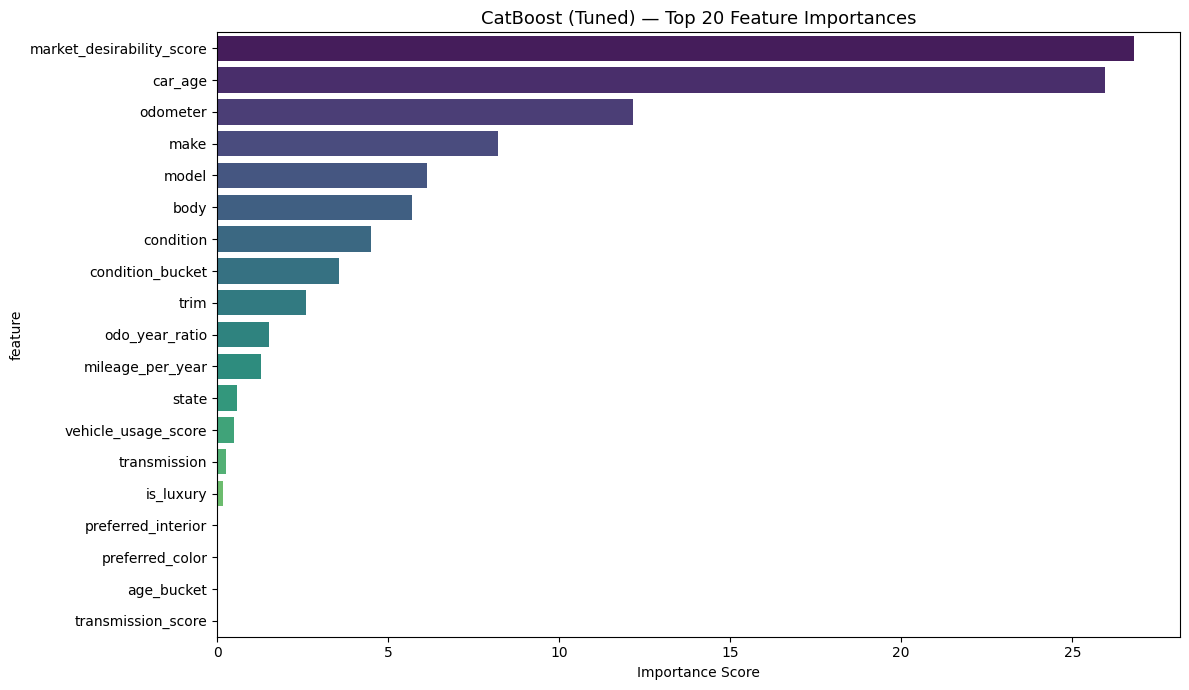

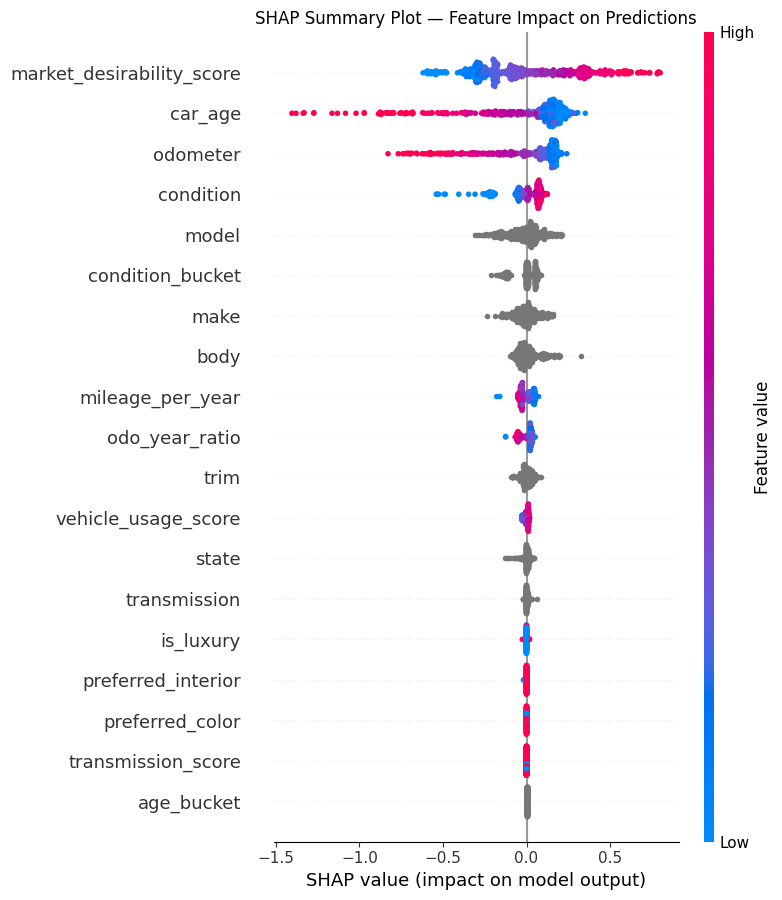

In [63]:
#PHASE13:-FEATURE IMPORTANCE +SHAP
importance = cat_tuned.get_feature_importance()
feat_names = X_train.columns
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=imp_df, palette='viridis')
plt.title('CatBoost (Tuned) — Top 20 Feature Importances', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

# SHAP
try:
    import shap
    explainer   = shap.TreeExplainer(cat_tuned)
    shap_sample = X_test.sample(min(500, len(X_test)), random_state=SEED)
    for col in cat_features_cb:
        if col in shap_sample.columns:
            shap_sample[col] = shap_sample[col].astype(str)
    shap_values = explainer.shap_values(shap_sample)
    plt.figure()
    shap.summary_plot(shap_values, shap_sample, show=False)
    plt.title('SHAP Summary Plot — Feature Impact on Predictions')
    plt.tight_layout()
    plt.savefig('shap_summary.png', bbox_inches='tight')
    plt.show()
except ImportError:
    print('shap not installed. Run: pip install shap')


## PHASE 13 :- ERROR ANALYSIS — WORST CASES

In [65]:
#PHASE14:-ERROR ANALYSIS - WORST CASES
error_df = X_test.copy()
error_df['actual_price']    = actual
error_df['predicted_price'] = predicted
error_df['abs_error']       = np.abs(actual - predicted)
error_df['pct_error']       = np.abs(actual - predicted) / actual * 100

print('TOP 20 WORST PREDICTIONS ')
worst = error_df.sort_values('abs_error', ascending=False).head(20)
display_cols = ['actual_price', 'predicted_price', 'abs_error', 'pct_error',
                'make', 'model', 'car_age', 'condition']
display_cols = [c for c in display_cols if c in worst.columns]
print(worst[display_cols].to_string())

print(f'\nMedian Absolute Error: ${error_df["abs_error"].median():,.2f}')
print(f'Mean Absolute % Error: {error_df["pct_error"].mean():.2f}%')


TOP 20 WORST PREDICTIONS 
        actual_price  predicted_price     abs_error    pct_error           make             model  car_age  condition
207240       36600.0      8544.203093  28055.796907    76.655183        unknown           unknown       20        4.3
168187        1200.0     26779.249004  25579.249004  2131.604084          dodge        challenger       11        4.6
150346       35000.0     10228.762099  24771.237901    70.774965        unknown           unknown       13        2.9
18768         9200.0     33920.084479  24720.084479   268.696570           ford             f-150       11        4.4
346750       40475.0     16000.270552  24474.729448    60.468757           ford            escape       13        2.5
169482       41500.0     17213.654596  24286.345404    58.521314        unknown           unknown       17        3.3
399189        4000.0     28077.827544  24077.827544   601.945689      chevrolet    silverado 1500       11        3.9
431371       36250.0     13503

## PHASE 14 :- SAVE MODEL + ENCODERS FOR BUILDING FURTHER MODEL

In [66]:
#PHASE15:- SAVE MODEL+ ENCODERS FOR BUILDING FURTHER MODEL
import pickle

# Save best model
cat_tuned.save_model('model_VITIKA.cbm')  # CatBoost native format
print('CatBoost model saved: model_VITIKA.cbm')

# Save encoders dict (all transformations needed at inference time)
encoders = {
    'cat_features'       : cat_features_cb,
    'preferred_colors'   : ['black', 'white', 'silver', 'gray'],
    'preferred_interiors': ['black', 'gray', 'beige', 'tan'],
    'luxury_brands'      : ['bmw', 'audi', 'mercedes-benz', 'lexus', 'porsche',
                             'jaguar', 'land rover', 'cadillac', 'lincoln'],
    'training_year'      : 2025,
    'odometer_clip'      : (lower_odo, upper_odo),
    'feature_columns'    : list(X_train.columns),
    'make_score_map'     : make_score.to_dict(),
    'model_score_map'    : model_score.to_dict(),
    'trim_score_map'     : trim_score.to_dict(),
    'body_score_map'     : body_score.to_dict(),
    'global_mean_price'  : df['sellingprice'].mean()
}

with open('encoders_VITIKA.pkl', 'wb') as f:
    pickle.dump(encoders, f)
print('Encoders saved: encoders_VITIKA.pkl')


CatBoost model saved: model_VITIKA.cbm
Encoders saved: encoders_VITIKA.pkl
